In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
application = pd.read_csv("application_record.csv")
credit = pd.read_csv("credit_record.csv")

In [3]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
print("Application Shape:", application.shape)
print("Credit Shape:", credit.shape)

Application Shape: (438557, 18)
Credit Shape: (1048575, 3)


In [6]:
application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [7]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [8]:
application = application.drop_duplicates()

credit = credit.drop_duplicates()

In [9]:
application = application.loc[:,~application.columns.duplicated()]

credit = credit.loc[:,~credit.columns.duplicated()]

In [10]:
num_cols = application.select_dtypes(include=["int64","float64"]).columns

num_cols

Index(['ID', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'CNT_FAM_MEMBERS'],
      dtype='str')

In [11]:
for col in num_cols:
    application[col].fillna(application[col].median(), inplace=True)

In [12]:
cat_cols = application.select_dtypes(include="object").columns

cat_cols

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='str')

In [13]:
for col in cat_cols:
    application[col].fillna(application[col].mode()[0], inplace=True)

In [14]:
application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [15]:
application.columns = application.columns.str.strip()

credit.columns = credit.columns.str.strip()

In [16]:
for col in cat_cols:
    application[col] = application[col].str.strip()

In [17]:
application.replace(["?", "NA", "N/A"], np.nan, inplace=True)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [18]:
for col in num_cols:
    application[col].fillna(application[col].median(), inplace=True)

for col in cat_cols:
    application[col].fillna(application[col].mode()[0], inplace=True)

In [19]:
data = pd.merge(
    application,
    credit,
    on="ID",
    how="inner"
)

In [20]:
data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [21]:
print(data.shape)

(777715, 20)


In [22]:
data["Age"] = abs(data["DAYS_BIRTH"]) // 365

In [23]:
data["Employment_Years"] = abs(data["DAYS_EMPLOYED"]) // 365

In [24]:
data["Employment_Years"] = data["Employment_Years"].replace(1000,0)

In [25]:
data["Income_Per_Person"] = (
    data["AMT_INCOME_TOTAL"] /
    data["CNT_FAM_MEMBERS"]
)

In [26]:
data["Age_Group"] = pd.cut(
    data["Age"],
    bins=[18,30,40,50,60,100],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60",
        "60+"
    ]
)

In [27]:
data["Income_Group"] = pd.cut(
    data["AMT_INCOME_TOTAL"],
    bins=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [28]:
categorical = data.select_dtypes(include="object").columns

categorical

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE', 'STATUS'],
      dtype='str')

In [29]:
encoder = LabelEncoder()

for col in categorical:
    data[col] = encoder.fit_transform(data[col])

In [30]:
data["Age_Group"] = LabelEncoder().fit_transform(data["Age_Group"])

data["Income_Group"] = LabelEncoder().fit_transform(data["Income_Group"])

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 777715 entries, 0 to 777714
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  int64  
 2   FLAG_OWN_CAR         777715 non-null  int64  
 3   FLAG_OWN_REALTY      777715 non-null  int64  
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  int64  
 7   NAME_EDUCATION_TYPE  777715 non-null  int64  
 8   NAME_FAMILY_STATUS   777715 non-null  int64  
 9   NAME_HOUSING_TYPE    777715 non-null  int64  
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL           777715 

In [32]:
data.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
MONTHS_BALANCE         0
STATUS                 0
Age                    0
Employment_Years       0
Income_Per_Person      0
Age_Group              0
Income_Group           0
dtype: int64

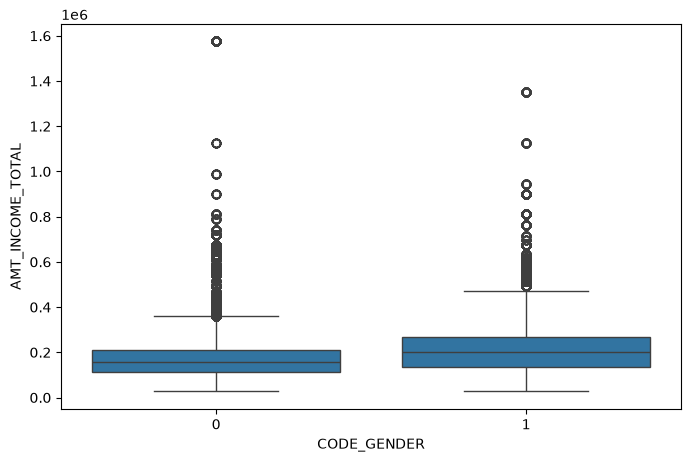

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="CODE_GENDER",
    y="AMT_INCOME_TOTAL",
    data=data
)

plt.show()

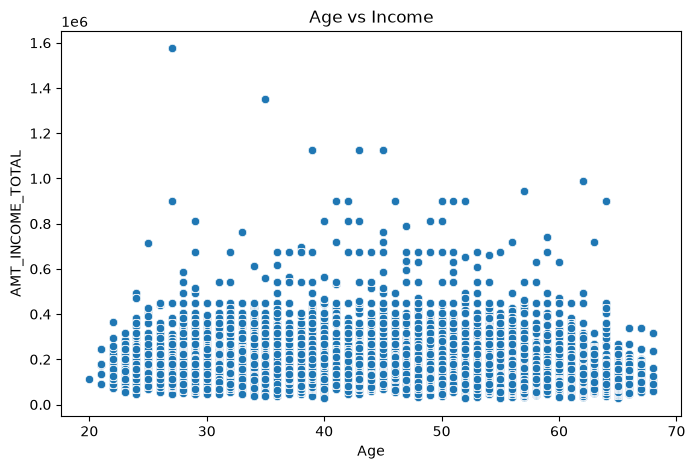

In [34]:

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="Age",
    y="AMT_INCOME_TOTAL"
)

plt.title("Age vs Income")
plt.show()


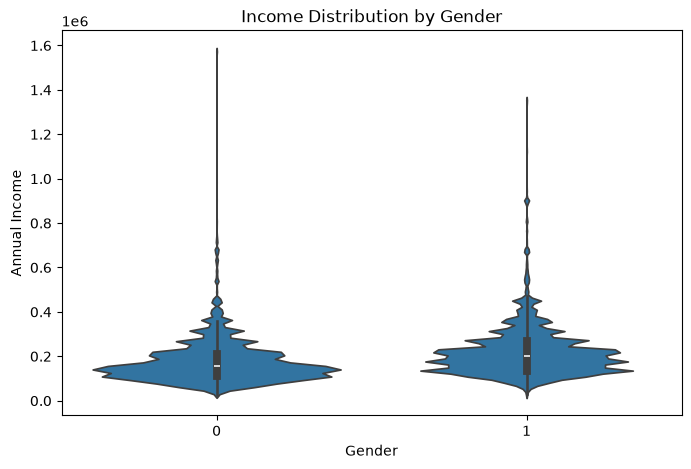

In [35]:


plt.figure(figsize=(8,5))

sns.violinplot(
    data=data,
    x="CODE_GENDER",
    y="AMT_INCOME_TOTAL"
)

plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Annual Income")

plt.show()

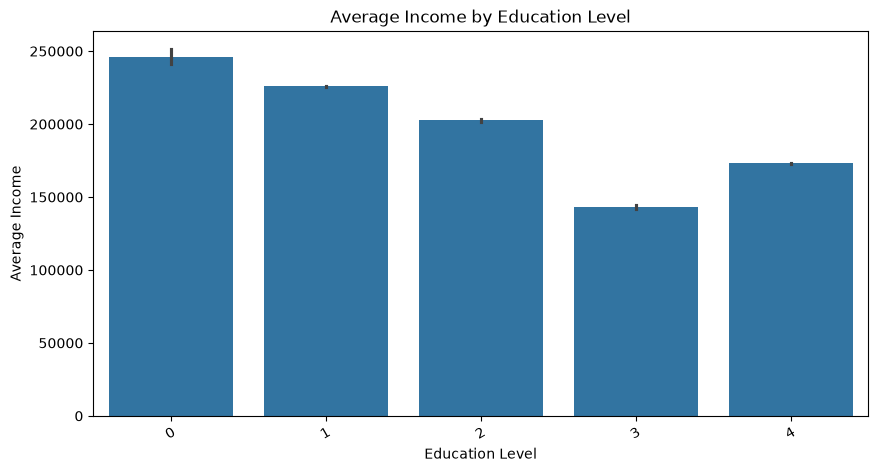

In [36]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=data,
    x="NAME_EDUCATION_TYPE",
    y="AMT_INCOME_TOTAL",
    estimator="mean"
)

plt.xticks(rotation=30)
plt.title("Average Income by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Income")

plt.show()

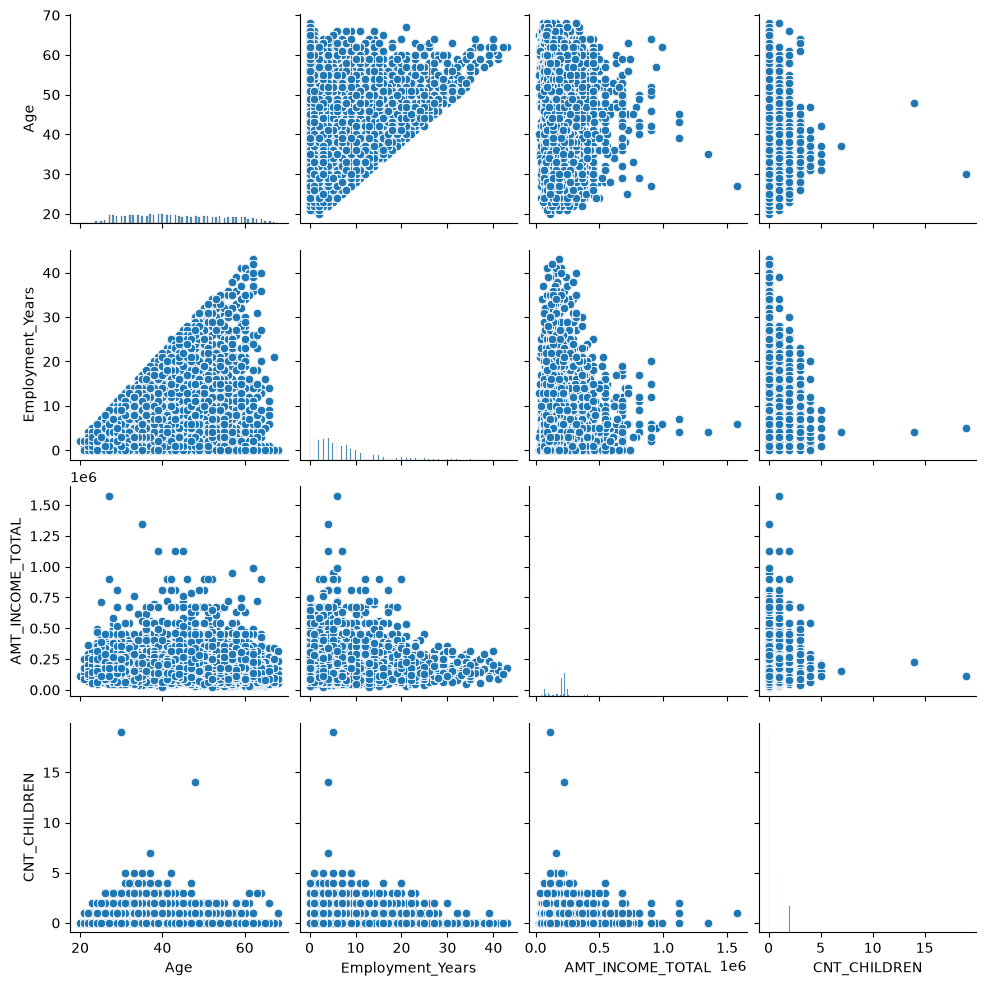

In [39]:
sns.pairplot(data[['Age',
                   'Employment_Years',
                   'AMT_INCOME_TOTAL',
                   'CNT_CHILDREN']])

plt.show()

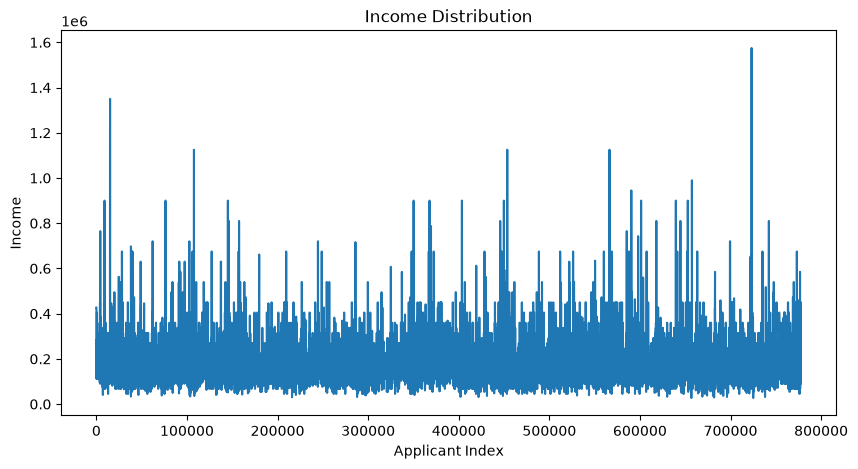

In [37]:
plt.figure(figsize=(10,5))

plt.plot(data["AMT_INCOME_TOTAL"])

plt.title("Income Distribution")
plt.xlabel("Applicant Index")
plt.ylabel("Income")

plt.show()

In [40]:
data.to_csv("credit_card_cleaned.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
